In [4]:
import torch

In [10]:
# create a 0D tensor (scalar) from a Python integer
tensor0d = torch.tensor(1)

# create a 1D tensor (vector) from a Python list
tensor1d = torch.tensor([1, 2, 3])

# create a 2D tensor from a nested Python list
tensor2d = torch.tensor([[1, 2], [3, 4]])

# create a 3D tensor from a nested Python list
tensor3d = torch.tensor([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])

# create a float tensor from a Python list
floatvec = torch.tensor([1.0, 2.0, 3.0])

In [6]:
tensor3d

tensor([[[1, 2],
         [3, 4]],

        [[5, 6],
         [7, 8]]])

In [8]:
print(tensor2d.dtype)

torch.int64


In [12]:
print(floatvec.dtype)

torch.float32


In [5]:
tensor2d = torch.tensor([[1, 2, 3],
                         [4, 5, 6]])
tensor2d

tensor([[1, 2, 3],
        [4, 5, 6]])

In [25]:
print(tensor2d.shape)

torch.Size([2, 3])


In [24]:
tensor2d.reshape(3, 2)

tensor([[1, 2],
        [3, 4],
        [5, 6]])

In [27]:
tensor2d.view(3,2)

tensor([[1, 2],
        [3, 4],
        [5, 6]])

In [28]:
tensor2d.T

tensor([[1, 4],
        [2, 5],
        [3, 6]])

In [6]:
tensor2d

tensor([[1, 2, 3],
        [4, 5, 6]])

In [7]:
tensor2d.matmul(tensor2d.T)

tensor([[14, 32],
        [32, 77]])

In [8]:
tensor2d @ tensor2d.T

tensor([[14, 32],
        [32, 77]])

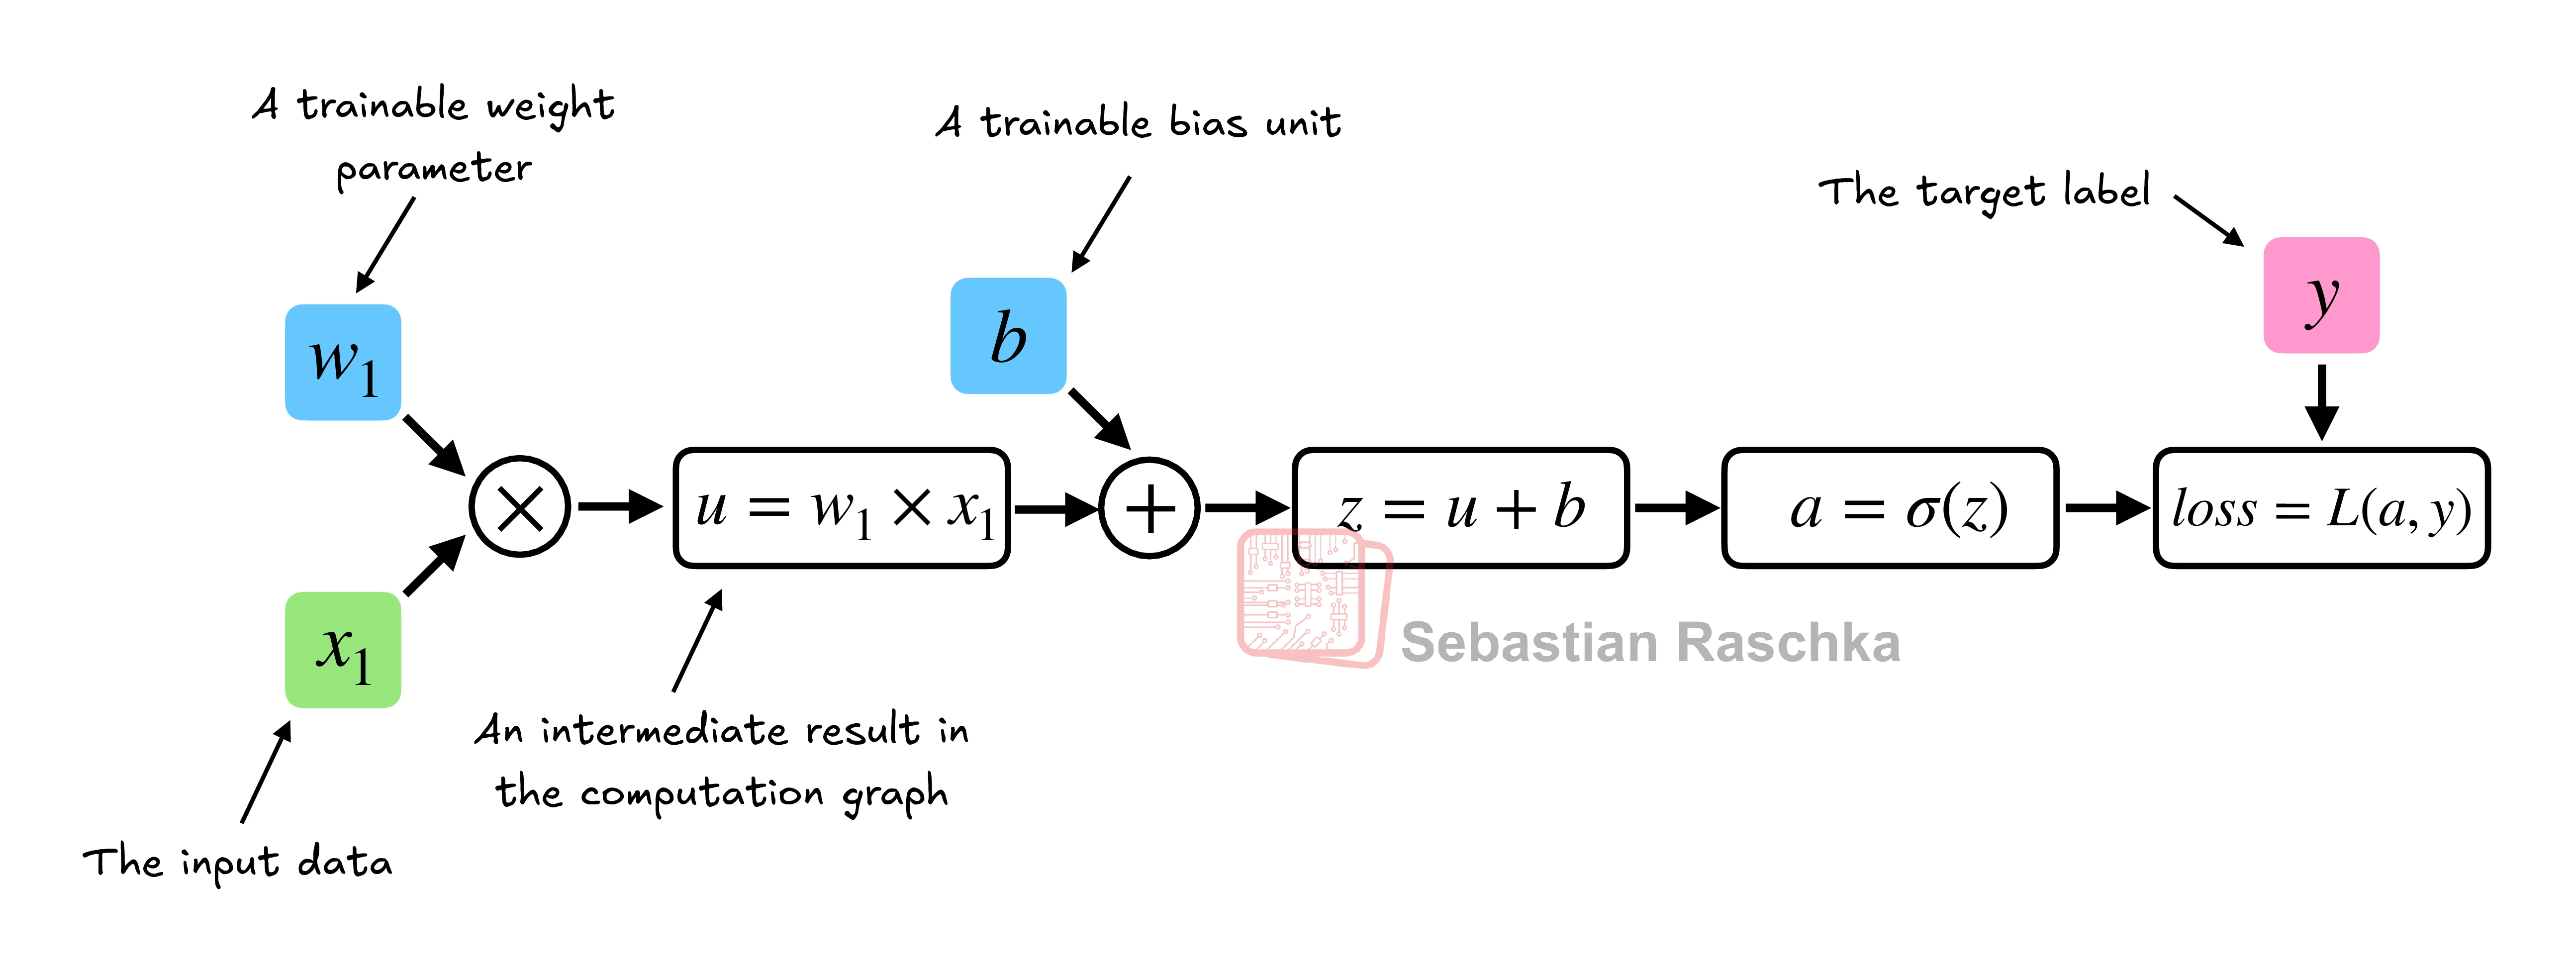

In [10]:
import torch.nn.functional as F

y = torch.tensor([1.0])  # true label
x1 = torch.tensor([1.1]) # input feature
w1 = torch.tensor([2.2]) # weight parameter
b = torch.tensor([0.0])  # bias unit

z = x1 * w1 + b          # net input
a = torch.sigmoid(z)     # activation & output

loss = F.binary_cross_entropy(a, y)
print(loss)

tensor(0.0852)


In [11]:
import torch.nn.functional as F
from torch.autograd import grad

y = torch.tensor([1.0])
x1 = torch.tensor([1.1])
w1 = torch.tensor([2.2], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

z = x1 * w1 + b
a = torch.sigmoid(z)

loss = F.binary_cross_entropy(a, y)

grad_L_w1 = grad(loss, w1, retain_graph=True)
grad_L_b = grad(loss, b, retain_graph=True)



In [12]:
print(grad_L_w1)
print(grad_L_b)

(tensor([-0.0898]),)
(tensor([-0.0817]),)


In [13]:
loss.backward()

print(w1.grad)
print(b.grad)

tensor([-0.0898])
tensor([-0.0817])


In [14]:
class NeuralNetwork(torch.nn.Module):
    def __init__(self, num_inputs, num_outputs):
        super().__init__()

        self.layers = torch.nn.Sequential(

            # 1st hidden layer
            torch.nn.Linear(num_inputs, 30),
            torch.nn.ReLU(),

            # 2nd hidden layer
            torch.nn.Linear(30, 20),
            torch.nn.ReLU(),

            # output layer
            torch.nn.Linear(20, num_outputs),
        )

    def forward(self, x):
        logits = self.layers(x)
        return logits

In [15]:
model = NeuralNetwork(50, 3)

In [16]:
print(model)

NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=50, out_features=30, bias=True)
    (1): ReLU()
    (2): Linear(in_features=30, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=3, bias=True)
  )
)


In [17]:
num_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)
print("Total number of trainable model parameters:", num_params)

Total number of trainable model parameters: 2213


In [18]:
print(model.layers[0].weight)

Parameter containing:
tensor([[ 0.0765,  0.0867, -0.0144,  ...,  0.0828, -0.1278, -0.0146],
        [ 0.0659,  0.1170,  0.0111,  ...,  0.0018, -0.0257, -0.1214],
        [-0.0723,  0.0047, -0.1228,  ...,  0.0616,  0.0150, -0.0360],
        ...,
        [ 0.1248, -0.1069,  0.1107,  ..., -0.0229, -0.0966,  0.0263],
        [-0.0458,  0.0756,  0.1124,  ...,  0.0331,  0.1032,  0.0451],
        [-0.0803,  0.1154, -0.1086,  ...,  0.0492,  0.0452,  0.0779]],
       requires_grad=True)


In [19]:
print(model.layers[0].weight.shape)

torch.Size([30, 50])


In [20]:
model.layers[0].bias

Parameter containing:
tensor([ 0.0458,  0.0570,  0.0507, -0.0950,  0.1325,  0.0463,  0.0915,  0.1378,
         0.0414, -0.0573,  0.1180,  0.0248,  0.0421,  0.0003,  0.0784, -0.1271,
        -0.0255, -0.1165, -0.0055,  0.0383,  0.1135, -0.0264,  0.0156,  0.0500,
         0.0124,  0.0035,  0.1329,  0.0112,  0.0251,  0.0716],
       requires_grad=True)

In [26]:
torch.manual_seed(123)

model = NeuralNetwork(50, 3)
print(model.layers[0].weight)

Parameter containing:
tensor([[-0.0577,  0.0047, -0.0702,  ...,  0.0222,  0.1260,  0.0865],
        [ 0.0502,  0.0307,  0.0333,  ...,  0.0951,  0.1134, -0.0297],
        [ 0.1077, -0.1108,  0.0122,  ...,  0.0108, -0.1049, -0.1063],
        ...,
        [-0.0787,  0.1259,  0.0803,  ...,  0.1218,  0.1303, -0.1351],
        [ 0.1359,  0.0175, -0.0673,  ...,  0.0674,  0.0676,  0.1058],
        [ 0.0790,  0.1343, -0.0293,  ...,  0.0344, -0.0971, -0.0509]],
       requires_grad=True)


In [30]:
torch.manual_seed(123)

X = torch.rand((1, 50))
# print(X)
out = model(X)
print(out)

tensor([[-0.1262,  0.1080, -0.1792]], grad_fn=<AddmmBackward0>)


In [29]:
with torch.no_grad():
    out = model(X)
print(out)

tensor([[-0.1262,  0.1080, -0.1792]])


In [34]:
with torch.no_grad():
    out = torch.softmax(model(X), dim=1)
print(out)
print(torch.sum(out))

tensor([[0.3113, 0.3934, 0.2952]])
tensor(1.)
